In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Setup

In [10]:
import os
os.makedirs("outputs", exist_ok=True)

import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")


Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128


## PyTorch Tensors

### Q1

In [11]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])
b = torch.zeros(2, 3)
c = torch.ones(4)

for name, t in [("a", a), ("b", b), ("c", c)]:
    print(f"--- {name} ---")
    print(f"  value:  {t}")
    print(f"  shape:  {t.shape}")
    print(f"  dtype:  {t.dtype}")
    print(f"  device: {t.device}")

# All three tensors live on CPU right now (device='cpu').
# When running a training loop, both model weights AND input tensors must be on
# the same device. If the weights are on GPU but the input is on CPU (or vice
# versa), PyTorch raises a RuntimeError because operations cannot mix across
# devices. Keeping everything on the GPU avoids expensive host<->device memory
# copies on every forward pass, which would destroy throughput.


--- a ---
  value:  tensor([[1., 2., 3.],
        [4., 5., 6.]])
  shape:  torch.Size([2, 3])
  dtype:  torch.float32
  device: cpu
--- b ---
  value:  tensor([[0., 0., 0.],
        [0., 0., 0.]])
  shape:  torch.Size([2, 3])
  dtype:  torch.float32
  device: cpu
--- c ---
  value:  tensor([1., 1., 1., 1.])
  shape:  torch.Size([4])
  dtype:  torch.float32
  device: cpu


### Q2

In [12]:
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])

print("Element-wise sqrt:", torch.sqrt(x))
print("Sum:              ", x.sum())
print("Mean:             ", x.mean())
print("Argmax index:     ", x.argmax())

# .argmax() returns the index of the highest-valued element in the tensor,
# NOT the value itself, just the position.  In a 1,000-class classifier, the
# model outputs a vector of 1,000 raw scores or probabilities. Calling
# .argmax() on that vector gives you the integer index of the class with the
# highest score, which you then look up in the class-label list to get the
# human-readable prediction.


Element-wise sqrt: tensor([1., 2., 3., 4., 5.])
Sum:               tensor(55.)
Mean:              tensor(11.)
Argmax index:      tensor(4)


### Q3

In [13]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

a_gpu  = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

a_back  = a_gpu.cpu()
a_numpy = a_back.numpy()
print(f"numpy type:   {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

# PyTorch requires .cpu() before .numpy() because NumPy arrays can only exist
# in CPU (host) memory. They have no concept of GPU memory whatsoever. A tensor
# on CUDA lives in device memory managed by the GPU driver; NumPy has no way to
# reference that memory address. Calling .cpu() first copies the data back to
# host RAM, making it accessible as a contiguous numpy array. This also tells
# us that NumPy is fundamentally a CPU-bound library; all its operations run
# on the host processor.


a_gpu device: cuda:0
numpy type:   <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


### Q4

In [ ]:
t = torch.arange(24).float()

t_4x6 = t.reshape(4, 6)
print("Shape (4, 6):", t_4x6.shape)

t_2x3x4 = t.reshape(2, 3, 4)
print("Shape (2, 3, 4):", t_2x3x4.shape)

t_batch = t_4x6.unsqueeze(0)
print("Shape after unsqueeze(0):", t_batch.shape)

# A single image tensor has shape (C, H, W) channels, height, width.
# Neural networks are built to process BATCHES, so they expect (N, C, H, W)
# where N is the batch size. When classifying one image at a time we still need
# that leading dimension to exist (even if N=1), otherwise the matrix
# multiplications inside the network produce shapes the layer weights don't
# expect and the forward pass crashes. .unsqueeze(0) inserts that size-1
# batch dimension at position 0, converting (C, H, W) -> (1, C, H, W).


Shape (4, 6): torch.Size([4, 6])
Shape (2, 3, 4): torch.Size([2, 3, 4])
Shape after unsqueeze(0): torch.Size([1, 4, 6])


### Q5

In [15]:
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a = torch.tensor(np_a, dtype=torch.float32)
t_b = torch.tensor(np_b, dtype=torch.float32)

np_result = np.matmul(np_a, np_b)
pt_result = torch.matmul(t_a, t_b)

print("NumPy result:\n", np_result)
print("PyTorch result:\n", pt_result)
print("Results match:", np.allclose(np_result, pt_result.numpy()))

# Every fully-connected (linear) layer in a neural network is essentially a
# matrix multiplication: output = input @ weight_matrix + bias. If the input
# to a layer is a (batch_size, in_features) tensor and the weight matrix is
# (in_features, out_features), the matmul produces (batch_size, out_features).
# This is the core compute primitive of deep learning. Convolutional layers are
# also implemented as matmuls under the hood. GPUs exist largely
# because they can execute thousands of these multiplications in parallel.


NumPy result:
 [[19. 22.]
 [43. 50.]]
PyTorch result:
 tensor([[19., 22.],
        [43., 50.]])
Results match: True


## Pretrained Models

### Model Q1

In [16]:
weights = ResNet18_Weights.DEFAULT
model   = models.resnet18(weights=weights)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# ResNet18 has ~11 million parameters. Training it from scratch on ImageNet
# required ~1.2 million labeled images, weeks of data curation, and days of
# multi-GPU compute resources most teams don't have. Starting from pretrained
# weights means all of that invested compute is available for free in two lines
# of code. In practice this matters enormously: instead of weeks you get a
# working baseline in minutes, which is the difference between shipping on a
# deadline and not shipping at all. Even when your target domain differs from
# ImageNet, the low-level features (edges, textures, gradients) that the first
# layers learned transfer well to almost any visual task.


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s] 


Total parameters:     11,689,512
Trainable parameters: 11,689,512


### Model Q2

In [ ]:
print(model)

# 1. The final layer is named 'fc' (fully connected). Its output size is 1000,
#    corresponding to the 1,000 ImageNet categories.
#
# 2. layer1 through layer4 are groups of residual blocks; each block contains
#    two or three convolutional layers with a skip connection that adds the
#    block's input to its output. Being "deep" means the network has many
#    successive non-linear transformations stacked on top of each other. Each
#    layer learns increasingly abstract representations: early layers detect
#    edges and colors; middle layers detect textures and parts; deep layers
#    detect high-level concepts like "snout" or "wheel arch". Without residual
#    skip connections, training very deep networks was unstable ResNet's
#    key insight was that skip connections let gradients flow cleanly across
#    many layers during backpropagation.


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Model Q3

In [18]:
model = model.to(device)
model.eval()
print("Model ready for inference.")

# .to(device): Moves all of the model's weight tensors from CPU memory to the
#   target device. This must match the device your input
#   tensors are on; PyTorch cannot run an operation that mixes CPU and GPU
#   tensors in the same forward pass.
#
# model.eval(): Switches the model to evaluation mode. This affects layers
#   that behave differently during training vs. inference:
#   - Dropout: In training mode dropout randomly zeroes activations to prevent
#     overfitting. In eval mode it is disabled, all neurons are active, so
#     predictions are deterministic.
#   - BatchNorm: In training mode it computes mean/variance from the current
#     batch. In eval mode it uses the running statistics accumulated during
#     training, which are more stable for single images or small batches.
#   Forgetting model.eval() before inference is a common bug that causes
#   non-deterministic outputs and artificially low confidence scores.


Model ready for inference.


### Model Q4

In [ ]:
preprocess = weights.transforms()
print(preprocess)

# Resize / CenterCrop to 224x224:
#   ResNet18's convolutional layers and fully-connected head expect a fixed
#   spatial input size. Images in the wild come in arbitrary sizes, so we 
#   resize the shorter side to 256 then crop the center to exactly 224x224. 
#   Using the same resize/crop that was applied during training ensures the 
#   distribution of pixel values the model sees at inference matches what it 
#   learned from.
#
# ToTensor():
#   Converts a PIL Image (pixel values 0–255, uint8) to a float32 tensor
#   with values in the range [0.0, 1.0]. The channel dimension also moves
#   from last to first (H, W, C) -> (C, H, W) to match PyTorch convention.
#
# Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
#   Subtracts the ImageNet channel means and divides by the channel standard
#   deviations, shifting the distribution of each channel to approximately
#   zero mean and unit variance. This is NOT arbitrary: these specific values
#   are the actual per-channel statistics of the ImageNet training set. The
#   model's weights were optimized assuming inputs with this exact distribution.
#   Using mean=0.5, std=0.5 instead would shift every input out of the expected
#   range, degrading predictions because the first-layer activations would be
#   systematically off from what the weights learned to handle.


ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## Running Inference

In [49]:
import random
random.seed(42)
DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    class_dir = DATA_DIR / label
    img_path  = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name

imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")


Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


### Inference Q1

In [ ]:
import torch.nn.functional as F

def get_top5_predictions(model, preprocess, image, device, class_labels):
    """
    Run inference on a PIL image and return the top-5 predictions.
    Returns a list of (class_name, probability) tuples.
    """
    # Step 1: Preprocess the image and add a batch dimension
    # (hint: use preprocess(), .unsqueeze(0), and .to(device))
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    # Step 2: Run inference inside a torch.no_grad() block
    # (hint: call model() on your input tensor to get output of shape (1, 1000))
    with torch.no_grad():
        output = model(input_tensor)   # shape: (1, 1000)

    # Step 3: Convert raw scores (logits) to probabilities
    # (hint: use torch.nn.functional.softmax on output[0])
    probs = F.softmax(output[0], dim=0)   # shape: (1000,)

    # Step 4: Get the top 5 predictions using torch.topk
    # (hint: returns top_probs and top_indices)
    top_probs, top_indices = torch.topk(probs, 5)

    # Step 5: Build and return a list of (class_name, probability) tuples
    return [(class_labels[idx.item()], prob.item())
            for idx, prob in zip(top_indices, top_probs)]


img, img_name = load_sample_image("mountain")
preds         = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")

# The top prediction "alp" (0.49) makes sense the image is a mountain scene
# and "alp" is ImageNet's closest equivalent to a snow-capped or rocky peak.
# The model is moderately confident but not fully committed, with "volcano"
# (0.21) and "valley" (0.20) splitting the remaining probability mass. This
# spread is expected: ImageNet has no "mountain" class, so probability
# distributes across several adjacent labels. "Alp", "volcano", and "valley"
# all describe elevated terrain or mountain-adjacent landscapes, so all three
# top predictions are semantically reasonable for this image. "Promontory"
# and "mountain tent" are weaker but still plausible given rocky outcroppings
# or camping context that may appear in the image. The vocabulary mismatch
# between ImageNet's 1,000 labels and the dataset's "mountain" category is
# working as expected the model is not wrong, it just speaks a different
# label language.



Top-5 predictions for '24204.jpg':
  alp                             0.4911
  volcano                         0.2076
  valley                          0.2016
  promontory                      0.0184
  mountain tent                   0.0169


### Inference Q2

In [ ]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]
    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")

# HIGH confidence:
#   "mountain" (ski: 0.593) and the visualization image (alp: 0.696) are the
#   most confident predictions. Visually distinctive snow and rock terrain
#   pushes probability mass toward a single label even when the exact label
#   is wrong (ski instead of alp).
#
# LOW confidence:
#   "sea" (seashore: 0.202) and "street" (unicycle: 0.130) are the weakest.
#   Sea spreads probability across seashore, breakwater, and geyser open
#   water scenes have ambiguous depth and horizon cues. Street is the worst:
#   top-1 is only 0.13 and the predictions (unicycle, triumphal arch,
#   jinrikisha) are picking up individual objects in a busy scene rather than
#   the scene category itself. This is the classic failure mode for complex
#   urban scenes too many competing objects, no dominant texture.
#
# Pattern: classes with a homogeneous dominant texture (mountain, glacier)
#   get more focused distributions even when the label is wrong. Classes with
#   many competing objects (street) or ambiguous global structure (sea) spread
#   probability thin across unrelated labels.
#
# Notable: "forest" predicting "viaduct" (0.385) as top-1 suggests the
#   specific image contains a bridge or structure cutting through the trees
#   the model is reacting to a salient object rather than the overall scene.
#   This is a good example of why top-1 accuracy alone is misleading; the
#   model isn't wrong about what it sees, it's just prioritizing the wrong
#   visual element for the task.



[buildings]  24258.jpg
  palace                          0.4301
  gondola                         0.1305
  monastery                       0.0624

[forest]  23309.jpg
  viaduct                         0.3853
  totem pole                      0.1089
  cliff                           0.0419

[glacier]  20272.jpg
  volcano                         0.3854
  valley                          0.3297
  promontory                      0.1216

[mountain]  20662.jpg
  ski                             0.5933
  alp                             0.3821
  snowmobile                      0.0071

[sea]  23069.jpg
  seashore                        0.2016
  breakwater                      0.1834
  geyser                          0.1718

[street]  24269.jpg
  unicycle                        0.1299
  triumphal arch                  0.1268
  jinrikisha                      0.1049


### Inference Q3

In [ ]:
img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = F.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

# The logit range (-4.84 to 7.08) shows unconstrained real-valued scores with
# no meaningful absolute scale a logit of 7.08 doesn't mean "70% confident",
# it just means that class scored highest relative to the others.
#
# After softmax, probabilities sum to exactly 1.0 and the max is only 0.1689
# ("worm fence"). This is low top-1 confidence the model is spreading
# probability across many classes for this forest image, which aligns with
# the Q2 result where "forest" produced unreliable predictions. The specific
# image likely has a structural element (fence, barrier) that dominates.
#
# Neural networks output logits internally for two reasons:
#   1. Numerical stability: CrossEntropyLoss applies log-softmax internally,
#      so passing logits avoids computing softmax then immediately taking log
#      of it, which loses floating-point precision.
#   2. No information loss: the relative gaps between logits are preserved.
#      Softmax compresses everything into [0,1] which can make small but
#      meaningful score differences hard to distinguish.
#
# For production confidence filtering: use PROBABILITIES.
#   A threshold of "flag predictions below 0.40 for human review" is
#   stakeholder-readable. This forest image at 0.169 would immediately
#   route to human review under that rule. Logit thresholds have no
#   intuitive meaning and vary across models.


Logit  range: min=-4.84, max=7.08
Prob   range: min=0.000001, max=0.1689
Probs sum to: 1.000000
Top prediction: worm fence  (0.1689)


### Inference Q4

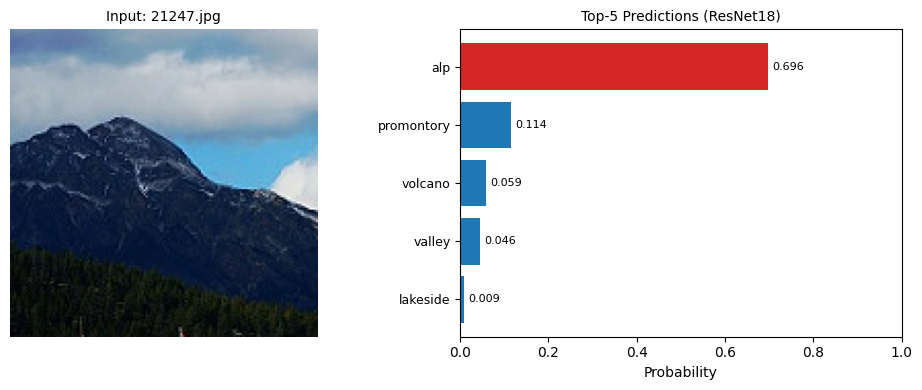

Saved to outputs/warmup_inference_viz.png


In [ ]:
img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

class_names = [p[0] for p in preds]
probs_list  = [p[1] for p in preds]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left panel: the image
axes[0].imshow(img)
axes[0].axis("off")
axes[0].set_title(f"Input: {img_name}", fontsize=10)

# Right panel: horizontal bar chart of top-5 probabilities
colors = ["#1f77b4" if i > 0 else "#d62728" for i in range(5)]
bars = axes[1].barh(range(5), probs_list[::-1], color=colors[::-1])
axes[1].set_yticks(range(5))
axes[1].set_yticklabels(class_names[::-1], fontsize=9)
axes[1].set_xlabel("Probability")
axes[1].set_title("Top-5 Predictions (ResNet18)", fontsize=10)
axes[1].set_xlim(0, 1)

# Annotate each bar with its probability value
for i, (bar, prob) in enumerate(zip(bars, probs_list[::-1])):
    axes[1].text(prob + 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{prob:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("outputs/warmup_inference_viz.png", dpi=150)
plt.show()
print("Saved to outputs/warmup_inference_viz.png")

# This image (21247.jpg) is a strong result "alp" at 0.696 means the model
# assigned nearly 70% of all probability mass to a single label, which is high
# confidence for a 1,000-class classifier. Looking at the image this makes
# sense: it shows a rocky, snow-dusted mountain peak with treeline and open
# sky, which maps cleanly onto ImageNet's "alp" category. The remaining
# top-5 labels (promontory, volcano, valley, lakeside) are all mountain-adjacent
# terrain concepts, so the model's uncertainty is distributed sensibly rather
# than leaking into unrelated categories.
#
# For a non-technical reviewer dashboard:
#   - Replace raw ImageNet labels with plain descriptions or the mapped
#     scene category ("mountain") so reviewers don't need to know ImageNet taxonomy.
#   - Color-code bars: green above 0.60 (confident), yellow 0.35-0.60,
#     red below 0.35 (send to human review).
#   - A reasonable auto-accept threshold for this task is top-1 >= 0.60.
#     This image would auto-accept. The forest image (top-1 ~0.39) would
#     route to human review.
